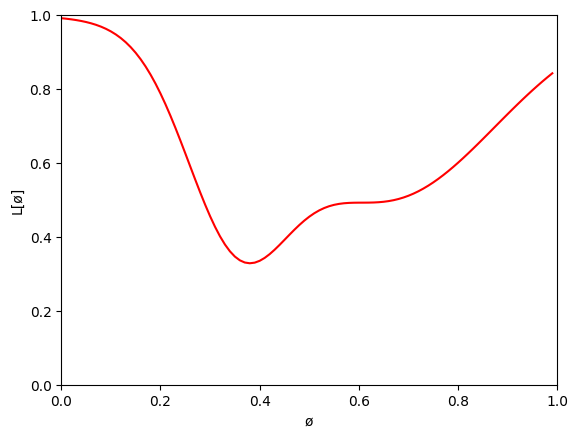

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def loss_function(phi):
    return 1- 0.5 * np.exp(-(phi-0.65)*(phi-0.65)/0.1) - 0.45 *np.exp(-(phi-0.35)*(phi-0.35)/0.02)

def draw_function(loss_function,a=None, b=None, c=None, d=None):
    phi_plot = np.arange(0,1,0.01)
    fig,ax = plt.subplots()
    ax.plot(phi_plot,loss_function(phi_plot),'r-')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel(r'ø'); ax.set_ylabel(r'L[ø]')
    if a is not None and b is not None and c is not None and d is not None:
      plt.axvspan(a, d, facecolor='k', alpha=0.2)
      ax.plot([a,a],[0,1],'b-')
      ax.plot([b,b],[0,1],'b-')
      ax.plot([c,c],[0,1],'b-')
      ax.plot([d,d],[0,1],'b-')
    plt.show()

draw_function(loss_function)


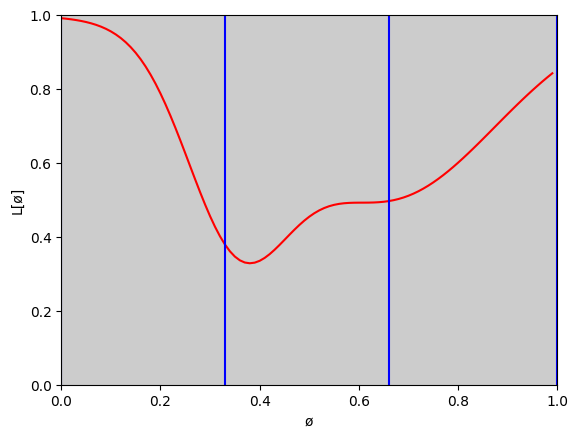

Iter 1, a=0.000, b=0.330, c=0.660, d=1.000


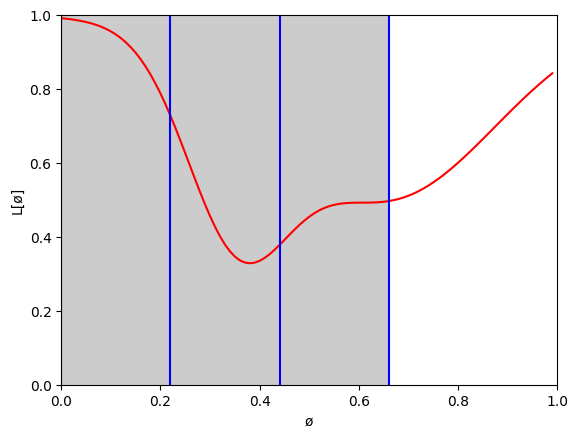

Iter 2, a=0.000, b=0.220, c=0.440, d=0.660


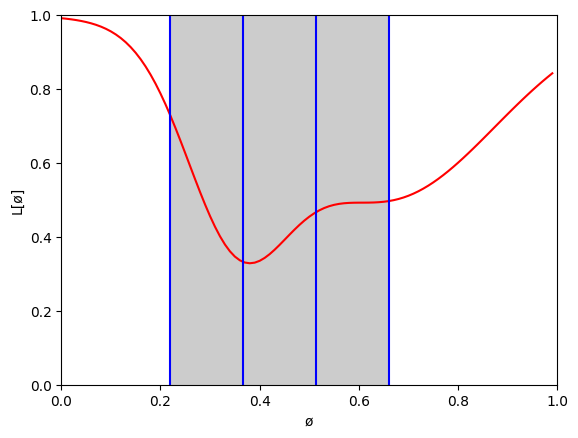

Iter 3, a=0.220, b=0.367, c=0.513, d=0.660


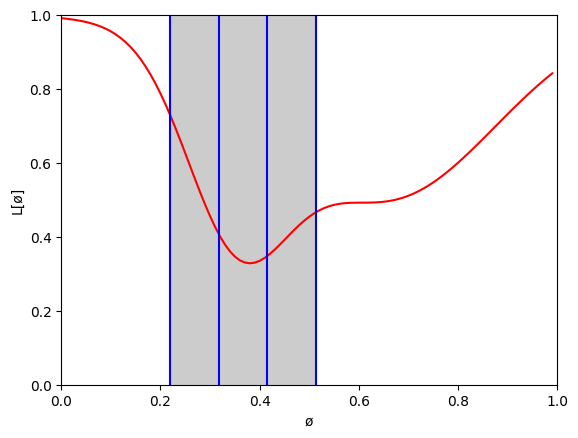

Iter 4, a=0.220, b=0.318, c=0.416, d=0.513


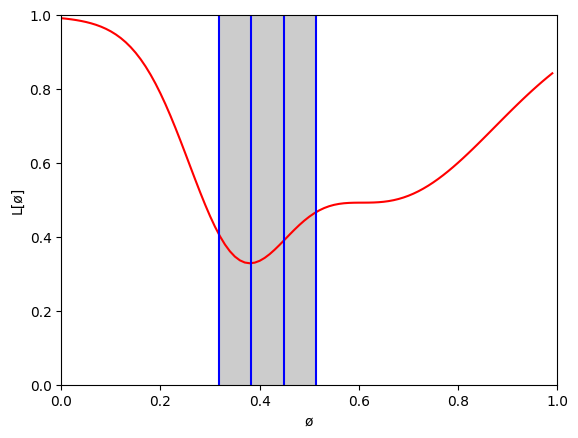

Iter 5, a=0.318, b=0.383, c=0.448, d=0.513


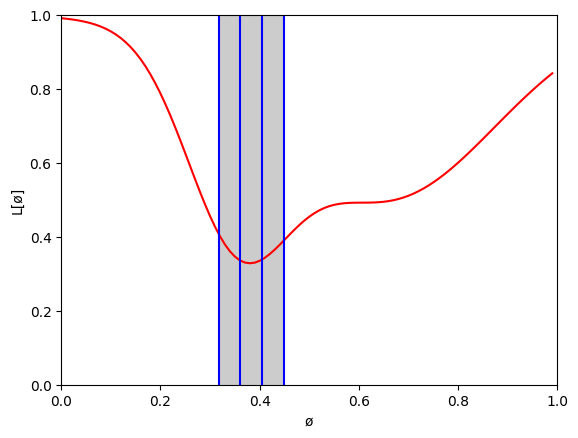

Iter 6, a=0.318, b=0.361, c=0.405, d=0.448


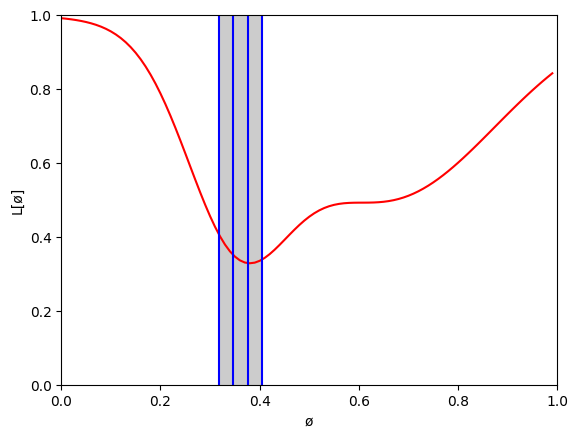

Iter 7, a=0.318, b=0.347, c=0.376, d=0.405


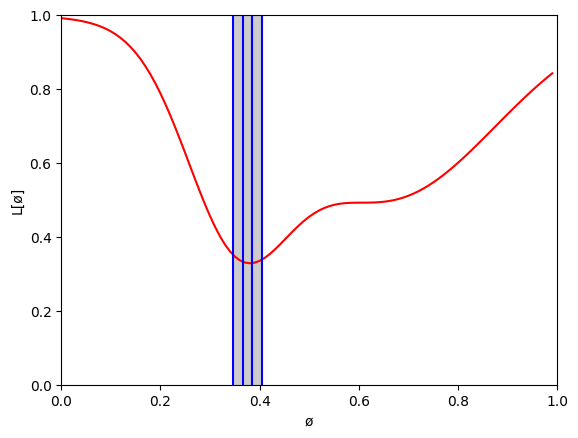

Iter 8, a=0.347, b=0.366, c=0.385, d=0.405


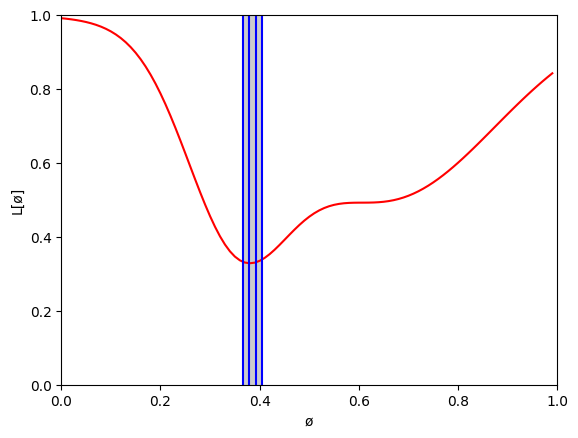

Iter 9, a=0.366, b=0.379, c=0.392, d=0.405


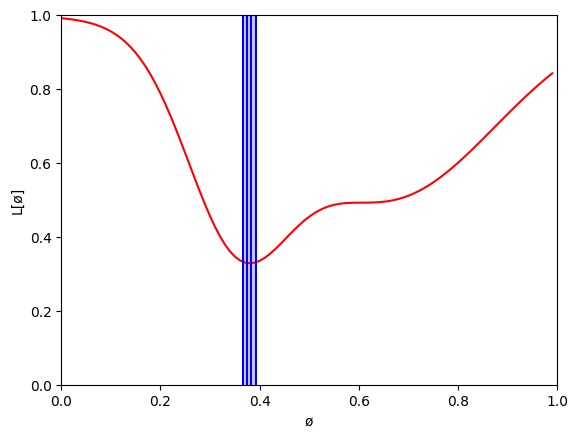

Iter 10, a=0.366, b=0.375, c=0.383, d=0.392
Soln = 0.383, loss = 0.329


In [4]:
def line_search(loss_function, thresh=.0001, max_iter = 10, draw_flag = False):
    a = 0
    b = 0.33
    c = 0.66
    d = 1.0
    n_iter = 0

    while np.abs(b-c) > thresh and n_iter < max_iter:
        n_iter = n_iter+1

        lossa = loss_function(a)
        lossb = loss_function(b)
        lossc = loss_function(c)
        lossd = loss_function(d)

        if draw_flag:
          draw_function(loss_function, a,b,c,d)

        print('Iter %d, a=%3.3f, b=%3.3f, c=%3.3f, d=%3.3f'%(n_iter, a,b,c,d))

        if lossa < lossb and lossa < lossc and lossa < lossd:
           b = a + (b - a) / 2
           c = a + (c - a) / 2
           d = a + (d - a) / 2
           continue

        if lossb < lossc:
           d = c
           b = a + (d-a) / 3
           c = a + 2*(d-a) / 3
           continue

        if lossc < lossb:
           a = b
           b = a + (d-a) / 3
           c = a + 2*(d-a) / 3
           continue
    
    soln = (b+c) / 2
    return soln

soln = line_search(loss_function, draw_flag=True)
print('Soln = %3.3f, loss = %3.3f'%(soln,loss_function(soln)))